# A Comparative Study of Classical and Quantum Variational Algorithms for Constrained Portfolio Optimization

**Author:** Ferrán Mata Infante  
**Date:** 2026-03-19

## Portfolio Optimization Problem

We want to construct an optimal investment portfolio from a set of available assets.  

The **goal** is to select the combination of assets that **maximizes return while minimizing risk**, subject to certain constraints (like total investment, diversification, or budget limits).

### Cost Function

For a portfolio represented by a binary vector $x = [x_1, x_2, ..., x_n]$, where:

- $x_i = 1$ if asset $i$ is included  
- $x_i = 0$ if asset $i$ is excluded  

we define the **cost function** as:

$
C(x) = - \mu^T x + q \, x^T \Sigma x + \lambda (\, \sum_i x_i -k)^2
$

Where:

- $\mu$ → vector of **expected annualized returns** of each asset  
- $\Sigma$ → **covariance matrix** of asset returns (risk measure)  
- $\lambda$ → risk aversion coefficient (balances return vs risk)

Minimizing $C(x)$ is equivalent to **maximizing return while controlling portfolio risk**.

### Constraints

Portfolio selection is usually subject to constraints:

1. **Cardinality constraint**: limit on the number of assets included in the portfolio  
2. **Budget constraint**: total investment cannot exceed available capital  
3. **Diversification constraints**: enforce exposure limits per sector or asset  

Formally, the optimization problem is:

$
\begin{aligned}
\min_{x \in \{0,1\}^n} \quad & C(x) = - \mu^T x + \lambda \, x^T \Sigma x \\
\text{s.t.} \quad & \sum_i x_i = k \quad \text{(select exactly k assets)} \\
& x_i \in \{0,1\}, \; \forall i
\end{aligned}
$

This is a **constrained combinatorial optimization problem**, which is **NP-hard**, making it a perfect candidate for:

- Classical heuristics (e.g., Simulated Annealing, Genetic Algorithms)  
- Quantum algorithms (e.g., QAOA for portfolio selection)  


Now, we install all the required dependencies for:

In [16]:
# pip install yfinance
#import numpy as np
from pennylane import numpy as np
import itertools
import yfinance as yf
import pandas as pd
import random
from collections import Counter
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import qaoa
import qulacs

import BruteForce_utils as bruteforce
import Classical_utils as classical
import SimulatedAnnealing_utils as simulated_annealing

**Download the Data**

In this section, we define a portfolio of stocks and download their historical prices from Yahoo Finance.

We will then calculate the daily log returns, expected annualized returns, and the covariance matrix for risk assessment.

In [17]:
# 1. Define tickers (Stock market identifiers)
# TEF.MC (Telefónica), SAN.MC (Santander), ITX.MC (Inditex), IBE.MC (Iberdrola)
tickers = ['TEF.MC', 'SAN.MC', 'ITX.MC', 'IBE.MC']

# 2. Download historical data (last 2 years)
data = yf.download(tickers, period="2y")['Close']

# 3. Calculate daily log returns
returns = np.log(data / data.shift(1)).dropna()

# Calculate inputs for the cost function (QUBO)
# Annualized mean return (assuming 252 trading days per year)
mu = returns.mean().values * 252

# Annualized covariance matrix (measures risk and asset correlation)
sigma = returns.cov().values * 252

classical.show_data(tickers, mu, sigma)

[*********************100%***********************]  4 of 4 completed

--- REAL-WORLD DATA EXTRACTED ---
TEF.MC: Expected Annual Return = 0.3252
SAN.MC: Expected Annual Return = 0.0802
ITX.MC: Expected Annual Return = 0.4321
IBE.MC: Expected Annual Return = 0.0385

Covariance Matrix (Sigma):
[[0.02600812 0.00753241 0.0099517  0.0120977 ]
 [0.00753241 0.05542257 0.02553427 0.00934836]
 [0.0099517  0.02553427 0.09096829 0.0119027 ]
 [0.0120977  0.00934836 0.0119027  0.04516934]]


**Model Parameters**

In [28]:
# Model parameters
q = 0.5        # Risk aversion parameter
K = 2          # Number of assets to select (budget constraint)
lmbda = 5   # Penalty strength (Lagrange multiplier)
n_assets = len(tickers) # Number of tikers

**Seeing all the combinations**

Next, we can compute all possible combinations and analyze which one has the lowest energy.

In [29]:
results_sorted = bruteforce.brute_force_solver_smart(classical.get_cost,tickers, mu, sigma, q, K, lmbda)
best_classic_x = bruteforce.show_results_brute_force(results_sorted, tickers, K)

Checking only 6 valid portfolios (K=2)
--- PORTFOLIO RANKING ---
Top 1: (np.int64(1), np.int64(0), np.int64(1), np.int64(0)) | Cost: -0.6889 | VALID | Assets: ['TEF.MC', 'ITX.MC']
Top 2: (np.int64(0), np.int64(1), np.int64(1), np.int64(0)) | Cost: -0.4136 | VALID | Assets: ['SAN.MC', 'ITX.MC']
Top 3: (np.int64(0), np.int64(0), np.int64(1), np.int64(1)) | Cost: -0.3907 | VALID | Assets: ['ITX.MC', 'IBE.MC']
Top 4: (np.int64(1), np.int64(1), np.int64(0), np.int64(0)) | Cost: -0.3572 | VALID | Assets: ['TEF.MC', 'SAN.MC']
Top 5: (np.int64(1), np.int64(0), np.int64(0), np.int64(1)) | Cost: -0.3161 | VALID | Assets: ['TEF.MC', 'IBE.MC']
Top 6: (np.int64(0), np.int64(1), np.int64(0), np.int64(1)) | Cost: -0.0591 | VALID | Assets: ['SAN.MC', 'IBE.MC']

>>> BEST CLASSICAL SOLUTION: (np.int64(1), np.int64(0), np.int64(1), np.int64(0))


**Simulated Annealing**

Here, we use a classical probabilistic method to study the minimum energy based on the Boltzmann probability.


--- SIMULATED ANNEALING RESULTS ---
Best portfolio found: [1 0 1 0]
Cost: -0.6889
Selected tickers: ['TEF.MC', 'ITX.MC']
Meets K=2 constraint?: YES


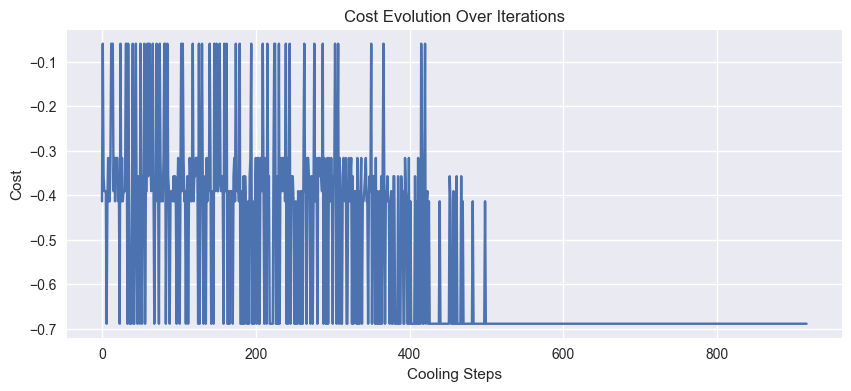

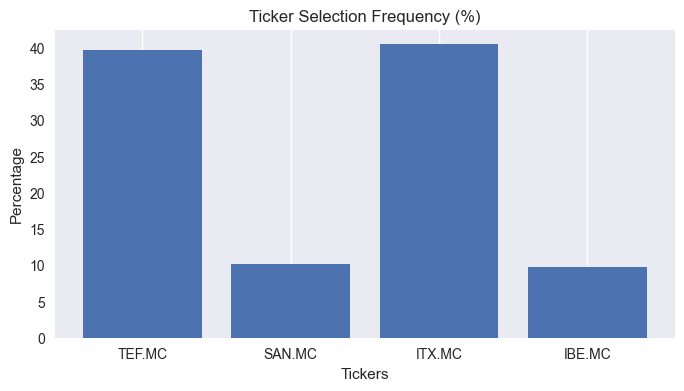


Top portfolio combinations:
(np.int32(1), np.int32(0), np.int32(1), np.int32(0)) -> 598964 times (65.32%)
(np.int32(0), np.int32(1), np.int32(1), np.int32(0)) -> 73588 times (8.02%)
(np.int32(0), np.int32(0), np.int32(1), np.int32(1)) -> 69574 times (7.59%)
(np.int32(1), np.int32(1), np.int32(0), np.int32(0)) -> 66193 times (7.22%)
(np.int32(1), np.int32(0), np.int32(0), np.int32(1)) -> 62052 times (6.77%)


In [ ]:
# Run simulated annealing with statistics
best_state_mc, best_cost_mc, history_mc, ticker_counts_mc, combo_counter_mc = simulated_annealing.simulated_annealing_stats(
    classical.get_cost, tickers, mu, sigma, q, K, lmbda,
    T_start=10.0, T_end=0.001, cooling_rate=0.99, iterations=1000)

# Plot results and statistics
simulated_annealing.plot_sa_results(best_state_mc, best_cost_mc, tickers, K, history_mc, ticker_counts_mc, combo_counter_mc)


# QAOA Algorithm

Here, we use Pennylane to determine the best configuration. We convert the energy function into a Hamiltonian, which serves as the cost Hamiltonian. Using this, we create a layer in a parametric circuit with a mixer. This process can be repeated and expanded as many times as desired to improve the optimization.

In [ ]:
def build_cost_hamiltonian(mu, sigma, q, K, lmbda, n_assets):
    coeffs = []
    obs = []

    # Lineal terms
    for i in range(n_assets):
        h_i = mu[i]/2  
        h_i += - lmbda/2 * (n_assets - 2*K)  
        h_i += - q/4 * sum(sigma[i,j] + sigma[j,i] for j in range(n_assets) if j != i)
        coeffs.append(h_i)
        obs.append(qml.PauliZ(i))

    # Bilinear terms
    for i in range(n_assets):
        for j in range(i+1, n_assets):
            J_ij = lmbda/4 + q*sigma[i,j]/4
            coeffs.append(J_ij)
            obs.append(qml.PauliZ(i) @ qml.PauliZ(j))

    # Return Hamiltonian
    return qml.Hamiltonian(coeffs, obs)
    

In [49]:
cost_h = build_cost_hamiltonian(mu, sigma, q, K, lmbda, n_assets)
mixer_h = sum([qml.PauliX(i) for i in range(n_assets)])
depth = 2  #Number of layers you want to put in the cirucit

We build the circuit:

In [56]:
def qaoa_layer(gamma, alpha):
    qaoa.cost_layer(gamma, cost_h)
    qaoa.mixer_layer(alpha, mixer_h)

def circuit(params, **kwargs):
    for w in range(n_assets):
        qml.Hadamard(wires=w)
    qml.layer(qaoa_layer, depth, params[0], params[1])


dev = qml.device("qulacs.simulator", wires=n_assets)

@qml.qnode(dev)
def cost_function(params):
    circuit(params)
    return qml.expval(cost_h)

# Create a drawer for the circuit
drawer = qml.draw(cost_function)

# Call the drawer with initial parameters
print(drawer([np.random.rand(depth), np.random.rand(depth)]))

0: ──H──RZ(0.98)─╭RZZ(1.13)─╭RZZ(1.13)─╭RZZ(1.13)──RX(1.93)──RZ(1.47)────────────────────── ···
1: ──H───────────╰RZZ(1.13)─│──────────│───────────RZ(1.09)─╭RZZ(1.13)─╭RZZ(1.13)──RX(1.93) ···
2: ──H──────────────────────╰RZZ(1.13)─│────────────────────╰RZZ(1.13)─│───────────RZ(0.93) ···
3: ──H─────────────────────────────────╰RZZ(1.13)──────────────────────╰RZZ(1.13)────────── ···

0: ··· ─╭RZZ(1.69)───────────╭RZZ(1.69)─╭RZZ(1.69)──RX(0.81)──────────────────────────────── ···
1: ··· ─╰RZZ(1.69)───────────│──────────│───────────RZ(1.63)─╭RZZ(1.69)─╭RZZ(1.69)──RX(0.81) ···
2: ··· ─╭RZZ(1.13)──RX(1.93)─╰RZZ(1.69)─│────────────────────╰RZZ(1.69)─│───────────RZ(1.39) ···
3: ··· ─╰RZZ(1.13)──RZ(1.11)──RX(1.93)──╰RZZ(1.69)──────────────────────╰RZZ(1.69)────────── ···

0: ··· ────────────────────────────────┤ ╭<𝓗>
1: ··· ────────────────────────────────┤ ├<𝓗>
2: ··· ─╭RZZ(1.69)──RX(0.81)───────────┤ ├<𝓗>
3: ··· ─╰RZZ(1.69)──RZ(1.66)──RX(0.81)─┤ ╰<𝓗>


We optimize the parametric circuit by seeking the minimum energy.

In [57]:
#optimizer = qml.AdamOptimizer(stepsize=0.05)
optimizer =  qml.GradientDescentOptimizer(stepsize=0.1)
steps = 70
params = np.array(([0.5,0.5],[0.5,0.5]), requires_grad=True)

best_energy = float('inf') 
best_params = None

for i in range(steps):
    params = optimizer.step(cost_function, params)
    current_energy = cost_function(params)

    if current_energy < best_energy:
        best_energy = current_energy
        best_params = params.copy() 
        
    if i % 5 == 0: 
        print(f"Step {i:3d} | E: {current_energy:10.4f} ")

print("\n" + "="*30)
print(f"OPTIMIZATION FINISHED")
print(f"Best energy found: {best_energy:.4f}")
print(f"Bes parameters: \n{best_params}")
print("="*30)



Step   0 | E:     0.7582 
Step   5 | E:     1.0392 
Step  10 | E:    -1.1210 
Step  15 | E:    -1.0793 
Step  20 | E:    -1.4967 
Step  25 | E:    -0.4188 
Step  30 | E:    -2.0461 
Step  35 | E:    -0.9568 
Step  40 | E:    -1.5170 
Step  45 | E:    -1.8152 
Step  50 | E:    -1.2122 
Step  55 | E:    -1.6413 
Step  60 | E:    -1.4505 
Step  65 | E:    -1.2419 

OPTIMIZATION FINISHED
Best energy found: -2.0461
Bes parameters: 
[[ 4.07832399 -4.07161059]
 [ 1.55548533  3.9915337 ]]


Finally, we use the parameterized circuit to obtain all the probabilities, and the state with the highest probability corresponds to the distribution of the optimized portfolios.

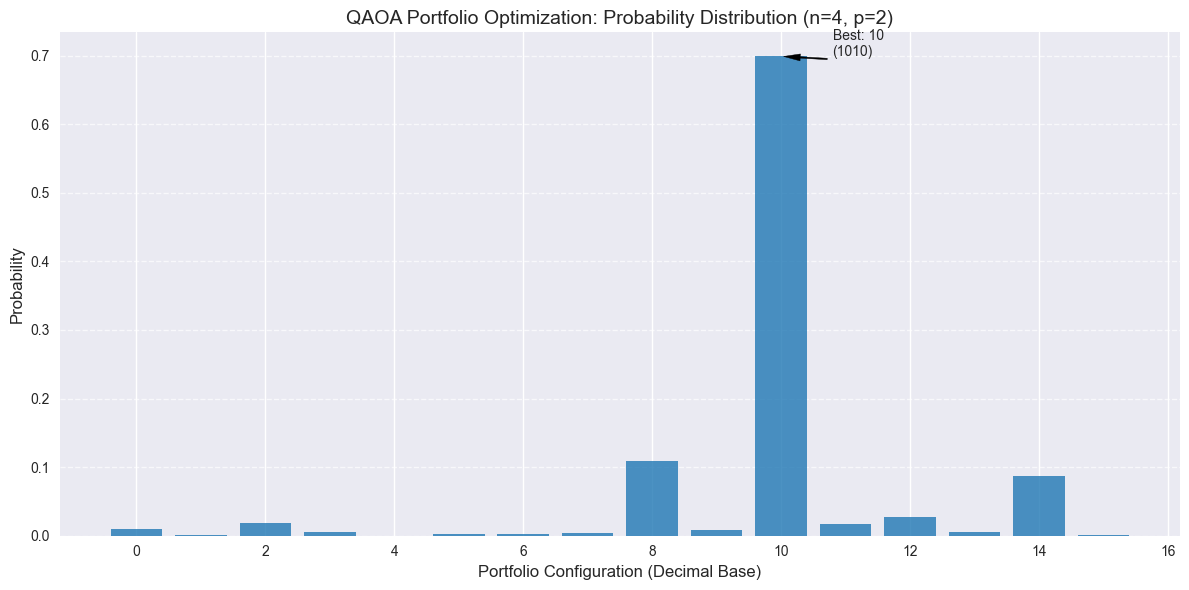

In [58]:
@qml.qnode(dev)
def probability_circuit(gamma, alpha):
    circuit([gamma, alpha])
    return qml.probs(wires=range(n_assets))

probs = probability_circuit(params[0], params[1])

plt.figure(figsize=(12, 6))
plt.style.use("seaborn-v0_8")

x_ax = range(2 ** n_assets)
plt.bar(x_ax, probs, color='#1f77b4', alpha=0.8)

plt.title(f"QAOA Portfolio Optimization: Probability Distribution (n={n_assets}, p={depth})", fontsize=14)
plt.xlabel("Portfolio Configuration (Decimal Base)", fontsize=12)
plt.ylabel("Probability", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)

best_idx = np.argmax(probs)
plt.annotate(f'Best: {best_idx}\n({format(best_idx, f"0{n_assets}b")})', 
             xy=(best_idx, probs[best_idx]), 
             xytext=(best_idx + (2**n_assets)*0.05, probs[best_idx]),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()
plt.show()

Here, we can see that the highest probability corresponds to the configuration 10 in decimal (1010 in binary), which matches the solution obtained with the previous methods.